CoxPH Model Summary


<lifelines.CoxPHFitter: fitted with 7032 total observations, 5163 right-censored observations>
             duration col = 'tenure'
                event col = 'Churn_flag'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7032
number of events observed = 1869
   partial log-likelihood = -14720.1254
         time fit was run = 2026-06-22 14:10:51 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
MonthlyCharges        -0.0008    0.9992    0.0009         -0.0025          0.0010              0.9975              1.0010
SeniorCitizen          0.0391    1.0398    0.0485         -0.0561          0.1342              0.9455              1.1436
Contract_OneYear      -1.0389    0.3538    0.0543         -1.1453         -0.9325              0.3181              0.3936
Contract_TwoYear      -1.5503    0.2122    0.0589         -1.6657         -1.4349              0.1891              0.2381
InternetService_Fiber  0.4208    1.5232    0.0523          0.3183          0.5233              1.3748              1.6876
OnlineSecurity_Yes    -0.5164    0.5967    0.0491         -0.6126         -0.4202              0.5419              0.6569
TechSupport_Yes       -0.4212    0.6562    0.0495         -0.5182         -0.3243              0.5956              0.7231
PaperlessBilling_Yes   0.2214    1.2478    0.0448          0.1335          0.3092              1.1428              1.3623

                       cmp to        z      p  -log2(p)
covariate                                              
MonthlyCharges         0.0000  -0.8773 0.3803    1.3948
SeniorCitizen          0.0000   0.8048 0.4209    1.2483
Contract_OneYear       0.0000 -19.1401 <5e-05  268.8489
Contract_TwoYear       0.0000 -26.3314 <5e-05  505.1889
InternetService_Fiber  0.0000   8.0478 <5e-05   50.0756
OnlineSecurity_Yes     0.0000 -10.5217 <5e-05   83.5920
TechSupport_Yes        0.0000  -8.5122 <5e-05   55.7019
PaperlessBilling_Yes   0.0000   4.9388 <5e-05   20.2785
---
Concordance = 0.8156
Partial AIC = 29456.2508
log-likelihood ratio test = 1865.8285 on 8 df
-log2(p) of ll-ratio test = inf

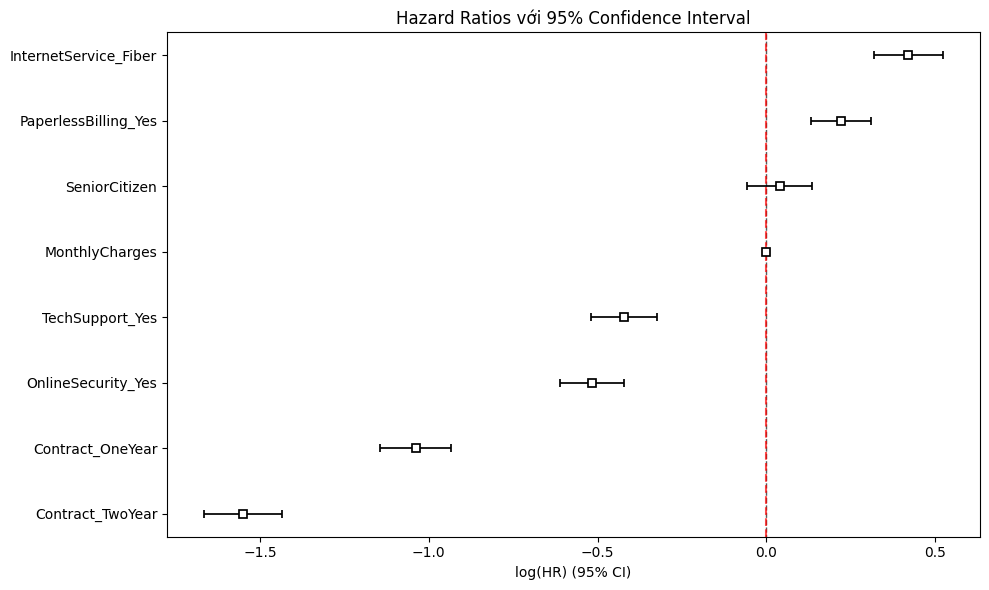


KIỂM TRA GIẢ ĐỊNH PROPORTIONAL HAZARDS
(Schoenfeld Residuals Test)



GIẢI THÍCH:
p > 0.05 → Biến đó THỎA giả định PH (tốt)
p < 0.05 → Biến đó VI PHẠM giả định PH (cần xử lý)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

# ── Load và chuẩn bị lại data ──
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['Churn_flag'] = (df['Churn'] == 'Yes').astype(int)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

# ── Encode categorical variables ──
# Chỉ lấy các biến có ý nghĩa business rõ ràng trước
df_cox = pd.DataFrame({
    'tenure'          : df['tenure'],
    'Churn_flag'      : df['Churn_flag'],
    'MonthlyCharges'  : df['MonthlyCharges'],
    'SeniorCitizen'   : df['SeniorCitizen'],
    'Contract_OneYear': (df['Contract'] == 'One year').astype(int),
    'Contract_TwoYear': (df['Contract'] == 'Two year').astype(int),
    'InternetService_Fiber': (df['InternetService'] == 'Fiber optic').astype(int),
    'OnlineSecurity_Yes'   : (df['OnlineSecurity'] == 'Yes').astype(int),
    'TechSupport_Yes'      : (df['TechSupport'] == 'Yes').astype(int),
    'PaperlessBilling_Yes' : (df['PaperlessBilling'] == 'Yes').astype(int),
})

# ── Fit Cox PH model ──
cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_cox, duration_col='tenure', event_col='Churn_flag')

# In summary đầy đủ
print("=" * 60)
print("CoxPH Model Summary")
print("=" * 60)
cph.print_summary(decimals=4)

# ── Plot hazard ratios ──
plt.figure(figsize=(10, 6))
cph.plot()
plt.title('Hazard Ratios với 95% Confidence Interval')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../reports/cox_hazard_ratios.png', dpi=150)
plt.show()

# ── QUAN TRỌNG: Kiểm tra giả định Proportional Hazards ──
print("\n" + "=" * 60)
print("KIỂM TRA GIẢ ĐỊNH PROPORTIONAL HAZARDS")
print("(Schoenfeld Residuals Test)")
print("=" * 60)

results = proportional_hazard_test(cph, df_cox, time_transform='rank')
results.print_summary(decimals=4)

print("\nGIẢI THÍCH:")
print("p > 0.05 → Biến đó THỎA giả định PH (tốt)")
print("p < 0.05 → Biến đó VI PHẠM giả định PH (cần xử lý)")



(7032, 11)
STRATIFIED Cox PH (Contract là strata, không phải covariate)


model,lifelines.CoxPHFitter
duration col,'tenure'
event col,'Churn_flag'
penalizer,0.1
l1 ratio,0.0
strata,Contract
baseline estimation,breslow
number of observations,7032
number of events observed,1869
partial log-likelihood,-13680.8853
time fit was run,2026-06-22 14:10:56 UTC


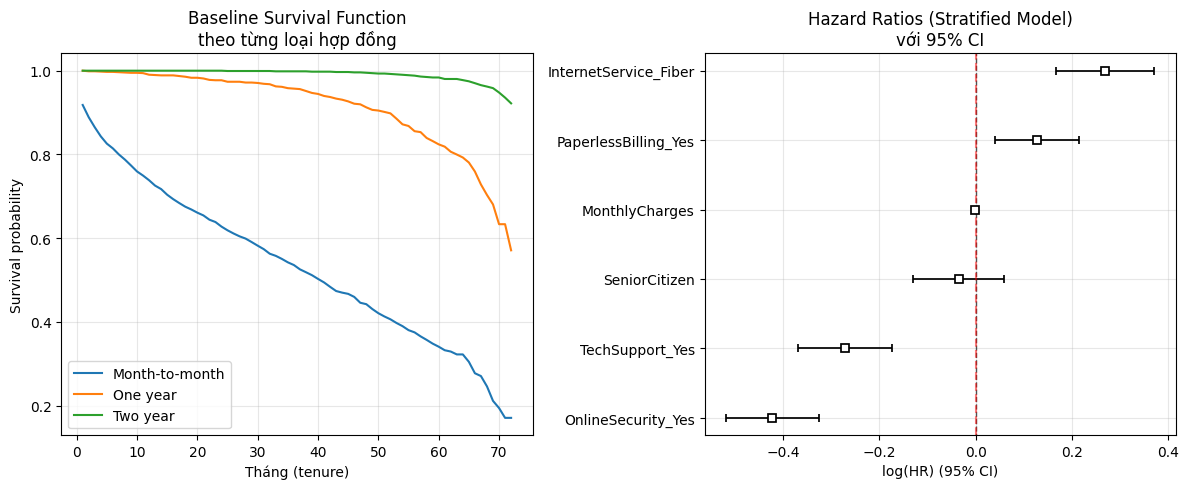

Kiểm tra PH assumption SAU KHI stratify:


Concordance Model gốc (không stratify):  0.8156
Concordance Stratified Model:             0.6239

→ Nếu stratified gần bằng hoặc cao hơn: model vừa đúng giả định, vừa fit tốt


In [2]:
#PHẦN 3: XỬ LÍ VI PHẠM
#1. LOAD CHUẨN BỊ DATA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

# Load lại data
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['Churn_flag'] = (df['Churn'] == 'Yes').astype(int)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

df_cox = pd.DataFrame({
    'tenure'               : df['tenure'],
    'Churn_flag'           : df['Churn_flag'],
    'MonthlyCharges'       : df['MonthlyCharges'],
    'SeniorCitizen'        : df['SeniorCitizen'],
    'Contract_OneYear'     : (df['Contract'] == 'One year').astype(int),
    'Contract_TwoYear'     : (df['Contract'] == 'Two year').astype(int),
    'InternetService_Fiber': (df['InternetService'] == 'Fiber optic').astype(int),
    'OnlineSecurity_Yes'   : (df['OnlineSecurity'] == 'Yes').astype(int),
    'TechSupport_Yes'      : (df['TechSupport'] == 'Yes').astype(int),
    'PaperlessBilling_Yes' : (df['PaperlessBilling'] == 'Yes').astype(int),
    'Contract'             : df['Contract'],  # giữ lại để stratify
})

print(df_cox.shape)
df_cox.head()

#2. Fit Stratified Cox PH model
# ── GIẢI PHÁP: Stratified Cox PH ──
# Stratify theo Contract → không ép giả định PH lên biến vi phạm nặng nhất
# Model sẽ estimate baseline hazard riêng cho từng nhóm Contract

cph_stratified = CoxPHFitter(penalizer=0.1)
cph_stratified.fit(
    df_cox.drop(columns=['Contract_OneYear', 'Contract_TwoYear']),
    duration_col='tenure',
    event_col='Churn_flag',
    strata=['Contract']  # <-- đây là chỗ khác biệt
)

print("=" * 60)
print("STRATIFIED Cox PH (Contract là strata, không phải covariate)")
print("=" * 60)
cph_stratified.print_summary(decimals=4)

#3. Vẽ biểu đồ (baseline survival + hazard ratios)
# ── So sánh đường cong baseline hazard giữa các nhóm Contract ──
plt.figure(figsize=(12, 5))

# Plot 1: Baseline survival theo từng nhóm Contract
ax1 = plt.subplot(1, 2, 1)
cph_stratified.baseline_survival_.plot(ax=ax1)
plt.title('Baseline Survival Function\ntheo từng loại hợp đồng')
plt.xlabel('Tháng (tenure)')
plt.ylabel('Survival probability')
plt.grid(True, alpha=0.3)

# Plot 2: Hazard ratios của các biến còn lại
ax2 = plt.subplot(1, 2, 2)
cph_stratified.plot(ax=ax2)
plt.title('Hazard Ratios (Stratified Model)\nvới 95% CI')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/cox_stratified.png', dpi=150)
plt.show()
#4. Kiểm tra lại PH assumption (đã fix lỗi KeyError)
# ── Kiểm tra lại PH assumption sau khi stratify ──
# GIỮ LẠI cột Contract vì model cần nó để biết strata
df_for_test = df_cox.drop(columns=['Contract_OneYear', 'Contract_TwoYear'])

results2 = proportional_hazard_test(
    cph_stratified,
    df_for_test,           # có Contract, không có Contract_OneYear/TwoYear
    time_transform='rank'
)
print("Kiểm tra PH assumption SAU KHI stratify:")
results2.print_summary(decimals=4)
#5. So sánh Concordance giữa 2 model
print(f"Concordance Model gốc (không stratify):  0.8156")
print(f"Concordance Stratified Model:             {cph_stratified.concordance_index_:.4f}")
print(f"\n→ Nếu stratified gần bằng hoặc cao hơn: model vừa đúng giả định, vừa fit tốt")

Stratified Cox PH + Time-Interaction (xử lý vi phạm PH còn lại)


model,lifelines.CoxPHFitter
duration col,'tenure'
event col,'Churn_flag'
penalizer,0.1
l1 ratio,0.0
strata,Contract
baseline estimation,breslow
number of observations,7032
number of events observed,1869
partial log-likelihood,-13202.6449
time fit was run,2026-06-22 14:11:03 UTC



Concordance: 0.8840


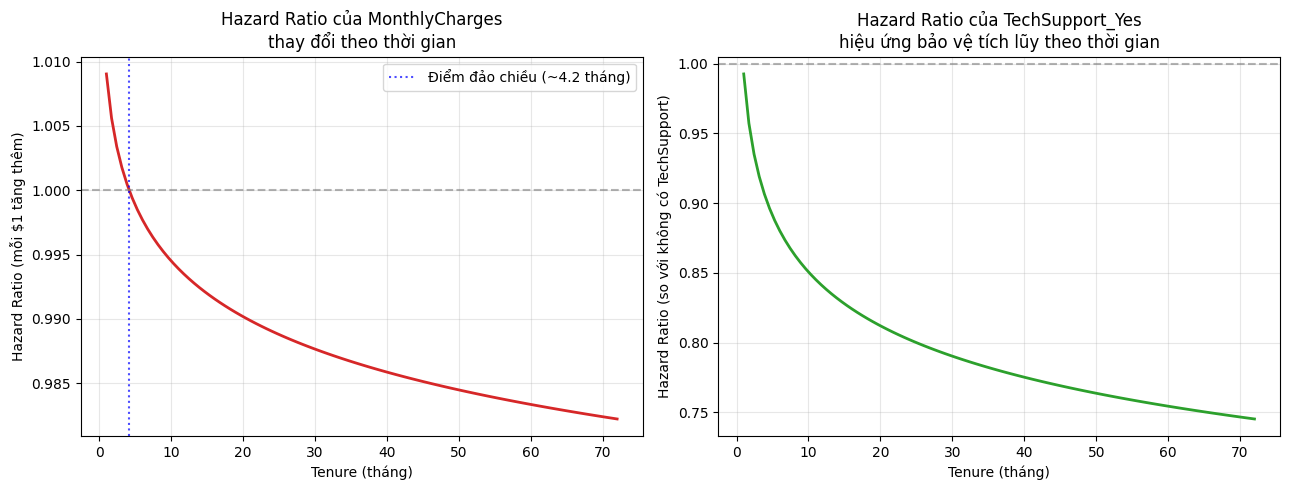

In [3]:
# thêm interaction với log(tenure)
import numpy as np

# ── Thêm time-interaction terms cho 2 biến vi phạm nặng ──
# Kỹ thuật chuẩn (Therneau & Grambsch): nhân covariate với log(duration)
# để model ước lượng trực tiếp xem hệ số thay đổi thế nào theo thời gian

df_cox_tv = df_cox.copy()
df_cox_tv['MonthlyCharges_x_logT'] = df_cox_tv['MonthlyCharges'] * np.log(df_cox_tv['tenure'])
df_cox_tv['TechSupport_x_logT']    = df_cox_tv['TechSupport_Yes'] * np.log(df_cox_tv['tenure'])

cph_tv = CoxPHFitter(penalizer=0.1)
cph_tv.fit(
    df_cox_tv.drop(columns=['Contract_OneYear', 'Contract_TwoYear']),
    duration_col='tenure',
    event_col='Churn_flag',
    strata=['Contract']
)

print("=" * 65)
print("Stratified Cox PH + Time-Interaction (xử lý vi phạm PH còn lại)")
print("=" * 65)
cph_tv.print_summary(decimals=4)
print(f"\nConcordance: {cph_tv.concordance_index_:.4f}")
#Vẽ biểu đồ minh họa
import matplotlib.pyplot as plt
import numpy as np

tenure_range = np.linspace(1, 72, 100)

# Hệ số time-varying cho MonthlyCharges
mc_effect = 0.0090 + (-0.0063) * np.log(tenure_range)
mc_hr = np.exp(mc_effect)

# Hệ số time-varying cho TechSupport
ts_effect = -0.0074 + (-0.0670) * np.log(tenure_range)
ts_hr = np.exp(ts_effect)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(tenure_range, mc_hr, color='#d62728', linewidth=2)
axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.6)
axes[0].axvline(x=4.2, color='blue', linestyle=':', alpha=0.7, label='Điểm đảo chiều (~4.2 tháng)')
axes[0].set_title('Hazard Ratio của MonthlyCharges\nthay đổi theo thời gian')
axes[0].set_xlabel('Tenure (tháng)')
axes[0].set_ylabel('Hazard Ratio (mỗi $1 tăng thêm)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(tenure_range, ts_hr, color='#2ca02c', linewidth=2)
axes[1].axhline(y=1, color='gray', linestyle='--', alpha=0.6)
axes[1].set_title('Hazard Ratio của TechSupport_Yes\nhiệu ứng bảo vệ tích lũy theo thời gian')
axes[1].set_xlabel('Tenure (tháng)')
axes[1].set_ylabel('Hazard Ratio (so với không có TechSupport)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/time_varying_effects.png', dpi=150)
plt.show()
#Lưu ý quan trọng: đoạn code này dùng số đã tính sẵn (0.0090, -0.0063, -0.0074, -0.0670) — chính là 4 hệ số từ bảng cph_tv.print_summary() bạn vừa chạy ở Cell trước đó. Nó không tự lấy từ model, mà tôi gõ tay từ kết quả bạn gửi — nên cell này chạy độc lập được, miễn là bạn đã chạy cell import matplotlib.pyplot as plt từ trước trong cùng notebook (thường đã có sẵn ở Cell 1).

In [8]:
#CLV Modeling 
import pandas as pd
import numpy as np

# ── Bước 1: Lấy survival function dự đoán cho từng khách hàng ──
horizon = 72  # giới hạn dự đoán = max tenure quan sát được trong data

surv_funcs = cph_tv.predict_survival_function(
    df_cox_tv.drop(columns=['tenure', 'Churn_flag',
                              'Contract_OneYear', 'Contract_TwoYear']),
    times=np.arange(1, horizon+1)
)

print("Shape của ma trận survival function:", surv_funcs.shape)
print("(hàng = mốc thời gian, cột = từng khách hàng)")
surv_funcs.iloc[:5, :5]  # xem thử 5 khách hàng đầu, 5 tháng đầu


#Tính RMST và CLV cho từng khách hàng
# ── Bước 2: Tính RMST (Restricted Mean Survival Time) ──
# RMST = tổng xác suất sống sót qua từng tháng = số tháng kỳ vọng còn lại
# (xấp xỉ Riemann sum: mỗi tháng đóng góp đúng 1 đơn vị thời gian × xác suất sống)

rmst = surv_funcs.sum(axis=0)  # cộng dồn theo cột (theo từng khách hàng)

# ── Bước 3: Tính CLV có chiết khấu theo thời gian ──
discount_rate_monthly = 0.01  # ~12.7%/năm, mức phổ biến cho phân tích CLV viễn thông

t_index = np.arange(1, horizon + 1)
discount_factors = 1 / (1 + discount_rate_monthly) ** t_index  # vector chiết khấu

# Nhân từng cột (khách hàng) với vector chiết khấu, theo hàng (thời gian)
discounted_surv = surv_funcs.multiply(discount_factors, axis=0)

# CLV = (tổng xác suất sống có chiết khấu) × doanh thu hàng tháng của khách đó
clv_factor = discounted_surv.sum(axis=0)  # 1 số/khách hàng: "hệ số CLV"
clv = clv_factor * df_cox_tv['MonthlyCharges'].values

# ── Gộp kết quả vào dataframe để xem ──
results_df = pd.DataFrame({
    'customerID'    : df['customerID'].values,
    'tenure_actual' : df_cox_tv['tenure'].values,
    'Churn_actual'  : df_cox_tv['Churn_flag'].values,
    'MonthlyCharges': df_cox_tv['MonthlyCharges'].values,
    'Contract'      : df_cox_tv['Contract'].values,
    'RMST_months'   : rmst.values,
    'CLV_discounted': clv.values
})

print("Thống kê mô tả RMST (số tháng kỳ vọng còn sống sót):")
print(results_df['RMST_months'].describe())

print("\nThống kê mô tả CLV (đã chiết khấu):")
print(results_df['CLV_discounted'].describe())

print("\nCLV trung bình theo loại hợp đồng:")
print(results_df.groupby('Contract')['CLV_discounted'].agg(['mean', 'median', 'count']))

results_df.head(10)



Shape của ma trận survival function: (72, 7032)
(hàng = mốc thời gian, cột = từng khách hàng)
Thống kê mô tả RMST (số tháng kỳ vọng còn sống sót):
count    7032.000000
mean       46.173039
std        21.850516
min         4.120402
25%        26.551854
50%        44.807486
75%        68.745347
max        71.840601
Name: RMST_months, dtype: float64

Thống kê mô tả CLV (đã chiết khấu):
count    7032.000000
mean     2221.263905
std      1468.893450
min        82.664581
25%       989.978674
50%      1929.010535
75%      3317.580901
max      6031.008918
Name: CLV_discounted, dtype: float64

CLV trung bình theo loại hợp đồng:
                       mean       median  count
Contract                                       
Month-to-month  2259.956599  2029.723911   3875
One year        2257.021775  1982.358459   1472
Two year        2101.044455  1510.158992   1685

MonthlyCharges trung bình theo Contract:
                     mean  median  count
Contract                                
Month-to-

Thống kê Remaining CLV (chỉ có ý nghĩa cho khách hàng ĐANG active):
count    5163.000000
mean     1011.098190
std       945.510225
min         0.000000
25%       293.356095
50%       741.169194
75%      1460.556926
max      4749.451695
Name: Remaining_CLV, dtype: float64

Remaining CLV trung bình theo Contract (chỉ khách hàng active):
                       mean       median  count
Contract                                       
Month-to-month  1522.464655  1257.764540   2220
One year         928.725321   732.980294   1306
Two year         383.331186   206.045023   1637


C:\Users\HP\AppData\Local\Temp\ipykernel_10512\741144884.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_by_contract, labels=contracts,


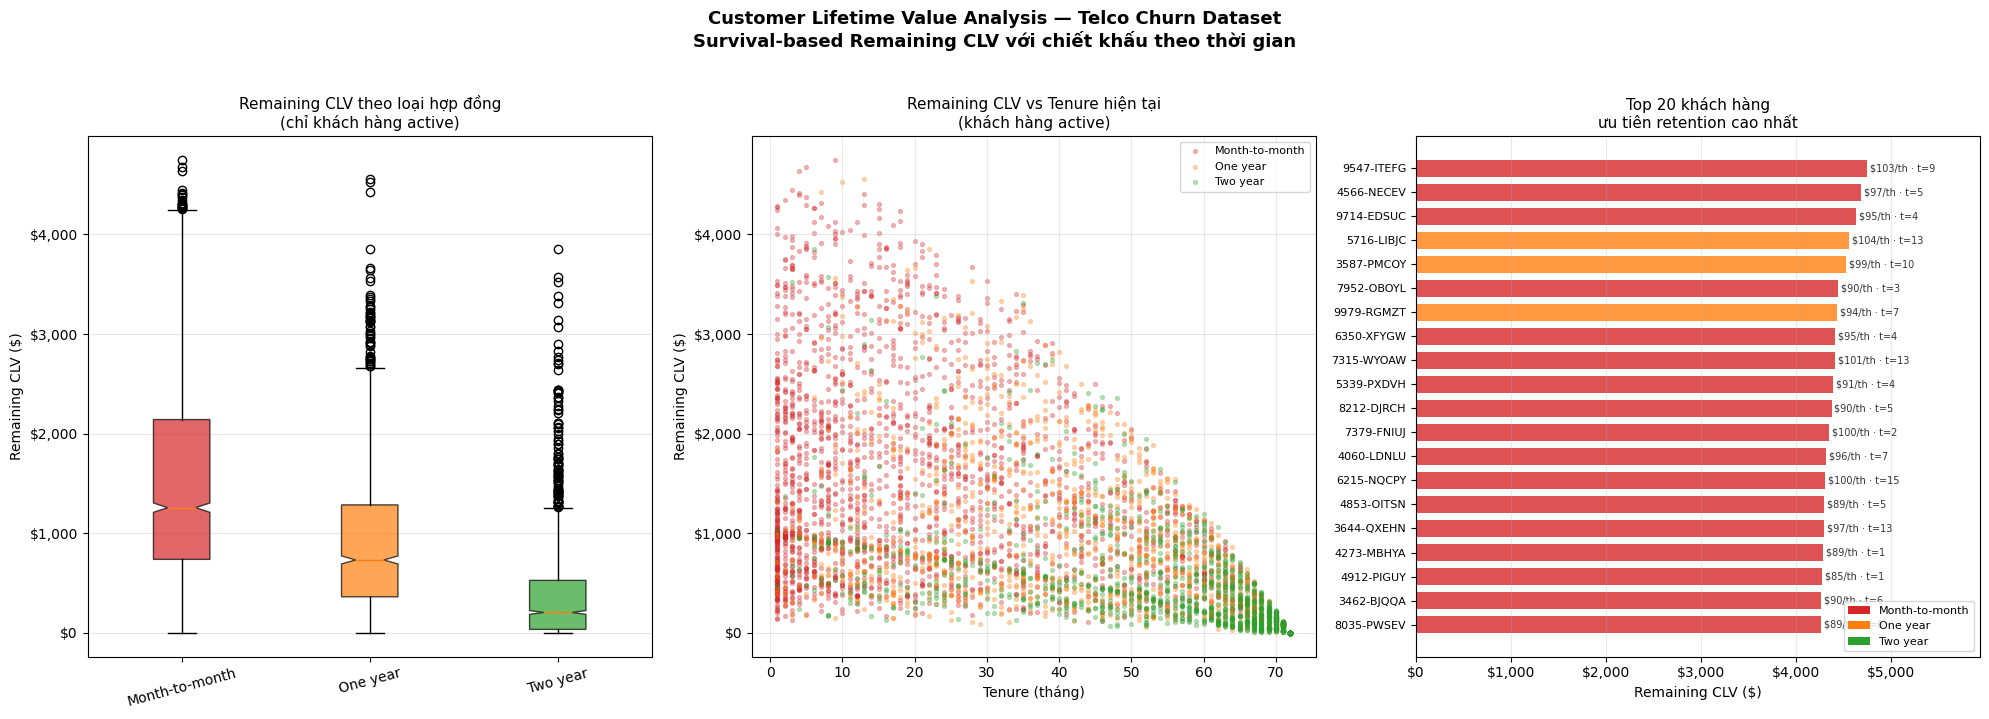


Tổng Remaining CLV của toàn bộ khách hàng active:
  $5,220,300

Nếu giữ được thêm 10% khách hàng Month-to-month có nguy cơ cao:
  Số khách hàng at-risk: 955
  Giá trị bảo vệ được: $236,381


In [11]:
#tính Remaining CLV đúng chuẩn
# ── Remaining CLV: CLV còn lại TỪ THỜI ĐIỂM HIỆN TẠI, có điều kiện trên việc đã sống sót ──

tenure_actual  = df_cox_tv['tenure'].values
churn_actual   = df_cox_tv['Churn_flag'].values
monthly_charge = df_cox_tv['MonthlyCharges'].values

surv_matrix = surv_funcs.values          # shape (72, 7032)
times = np.arange(1, horizon + 1)

# S(t0): xác suất sống tại đúng thời điểm hiện tại của từng khách hàng
t0_row_idx = tenure_actual - 1           # zero-based index vì times bắt đầu từ 1
S_t0 = surv_matrix[t0_row_idx, np.arange(len(tenure_actual))]
S_t0_safe = np.where(S_t0 > 1e-10, S_t0, 1e-10)   # tránh chia 0

# Mặt nạ: chỉ tính cho các mốc thời gian TƯƠNG LAI (t > t0)
time_matrix  = times.reshape(-1, 1)
mask_future  = time_matrix > tenure_actual.reshape(1, -1)

# Conditional survival: S(t)/S(t0), chỉ áp dụng cho phần tương lai
cond_surv = np.where(mask_future, surv_matrix / S_t0_safe.reshape(1, -1), 0.0)

# Chiết khấu tính từ THỜI ĐIỂM HIỆN TẠI (t - t0 tháng từ bây giờ), không phải từ t=0
months_ahead = np.where(mask_future, time_matrix - tenure_actual.reshape(1, -1), 0)
discount_remaining = 1 / (1 + discount_rate_monthly) ** months_ahead

remaining_clv_factor = (cond_surv * discount_remaining).sum(axis=0)
remaining_clv = remaining_clv_factor * monthly_charge

# Khách hàng ĐÃ CHURN: giá trị tương lai = 0 (họ đã rời, hết giá trị thu thêm)
remaining_clv = np.where(churn_actual == 1, 0.0, remaining_clv)

results_df['Remaining_CLV'] = remaining_clv

print("Thống kê Remaining CLV (chỉ có ý nghĩa cho khách hàng ĐANG active):")
print(results_df.loc[results_df['Churn_actual'] == 0, 'Remaining_CLV'].describe())

print("\nRemaining CLV trung bình theo Contract (chỉ khách hàng active):")
print(results_df[results_df['Churn_actual'] == 0]
      .groupby('Contract')['Remaining_CLV']
      .agg(['mean', 'median', 'count']))

results_df.sort_values('Remaining_CLV', ascending=False).head(10)

#Vẽ biểu đồ tổng kết CLV 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np


fig, axes = plt.subplots(1, 3, figsize=(20, 7))  # tăng chiều rộng và cao

# ── Biểu đồ 1: Boxplot (giữ nguyên) ──
active = results_df[results_df['Churn_actual'] == 0]
contracts = ['Month-to-month', 'One year', 'Two year']
colors = ['#d62728', '#ff7f0e', '#2ca02c']
color_map = {'Month-to-month': '#d62728', 'One year': '#ff7f0e', 'Two year': '#2ca02c'}

data_by_contract = [active[active['Contract'] == c]['Remaining_CLV'].values
                    for c in contracts]
bp = axes[0].boxplot(data_by_contract, labels=contracts,
                     patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Remaining CLV theo loại hợp đồng\n(chỉ khách hàng active)', fontsize=11)
axes[0].set_ylabel('Remaining CLV ($)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# ── Biểu đồ 2: Scatter (giữ nguyên) ──
for c in contracts:
    mask = (active['Contract'] == c)
    axes[1].scatter(active.loc[mask, 'tenure_actual'],
                    active.loc[mask, 'Remaining_CLV'],
                    c=color_map[c], label=c, alpha=0.3, s=8)
axes[1].set_title('Remaining CLV vs Tenure hiện tại\n(khách hàng active)', fontsize=11)
axes[1].set_xlabel('Tenure (tháng)')
axes[1].set_ylabel('Remaining CLV ($)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# ── Biểu đồ 3: Top 20 — FIX label bị chồng ──
top20 = (active.sort_values('Remaining_CLV', ascending=False)
         .head(20)
         .reset_index(drop=True))

bar_colors = [color_map[c] for c in top20['Contract']]

# Label đơn giản hơn: chỉ customerID, tách dòng MonthlyCharges ra annotation riêng
simple_labels = [f"{r['customerID']}" for _, r in top20.iterrows()]

bars = axes[2].barh(range(20), top20['Remaining_CLV'],
                    color=bar_colors, alpha=0.8, height=0.7)

# Ghi MonthlyCharges + tenure trực tiếp lên bar (tránh nhét vào y-label)
for i, (_, r) in enumerate(top20.iterrows()):
    axes[2].text(
        top20['Remaining_CLV'].iloc[i] + 30,   # offset nhỏ sau bar
        i,
        f"${r['MonthlyCharges']:.0f}/th · t={r['tenure_actual']}",
        va='center', fontsize=7, color='#333333'
    )

axes[2].set_yticks(range(20))
axes[2].set_yticklabels(simple_labels, fontsize=8)
axes[2].invert_yaxis()
axes[2].set_title('Top 20 khách hàng\nưu tiên retention cao nhất', fontsize=11)
axes[2].set_xlabel('Remaining CLV ($)')
axes[2].grid(True, alpha=0.3, axis='x')
axes[2].set_xlim(0, top20['Remaining_CLV'].max() * 1.25)  # thêm khoảng trống cho annotation
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[c], label=c) for c in contracts]
axes[2].legend(handles=legend_elements, fontsize=8, loc='lower right')

plt.suptitle('Customer Lifetime Value Analysis — Telco Churn Dataset\n'
             'Survival-based Remaining CLV với chiết khấu theo thời gian',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../reports/clv_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTổng Remaining CLV của toàn bộ khách hàng active:")
print(f"  ${active['Remaining_CLV'].sum():,.0f}")
print(f"\nNếu giữ được thêm 10% khách hàng Month-to-month có nguy cơ cao:")
at_risk = active[(active['Contract']=='Month-to-month') &
                 (active['Remaining_CLV'] > active['Remaining_CLV'].quantile(0.75))]
print(f"  Số khách hàng at-risk: {len(at_risk)}")
print(f"  Giá trị bảo vệ được: ${at_risk['Remaining_CLV'].sum() * 0.10:,.0f}")

In [15]:
#Bước tiếp theo: Streamlit App
#Trước khi tôi viết code Streamlit, bạn cần lưu model và data để app load được mà không phải train lại mỗi lần chạy. Chạy cell này ngay:
import pickle, os

os.makedirs('../app', exist_ok=True)

# Lưu model
with open('../app/cph_tv_model.pkl', 'wb') as f:
    pickle.dump(cph_tv, f)

# Lưu results dataframe
results_df.to_csv('../app/results_clv.csv', index=False)

# Lưu df_cox_tv để app dùng predict
df_cox_tv.to_csv('../app/df_cox_tv.csv', index=False)

# Lưu df gốc để lookup customerID
df.to_csv('../app/df_original.csv', index=False)

print("Đã lưu:")
print("  ../app/cph_tv_model.pkl")
print("  ../app/results_clv.csv")
print("  ../app/df_cox_tv.csv")
print("  ../app/df_original.csv")

# Kiểm tra size
for fname in ['cph_tv_model.pkl', 'results_clv.csv', 'df_cox_tv.csv', 'df_original.csv']:
    size = os.path.getsize(f'../app/{fname}') / 1024
    print(f"  {fname}: {size:.1f} KB")

Đã lưu:
  ../app/cph_tv_model.pkl
  ../app/results_clv.csv
  ../app/df_cox_tv.csv
  ../app/df_original.csv
  cph_tv_model.pkl: 554.5 KB
  results_clv.csv: 584.3 KB
  df_cox_tv.csv: 432.2 KB
  df_original.csv: 968.0 KB
